# 03 — feature engineering & target forward-looking

> etapa 4a do datathon FIAP fase 5 — associação passos mágicos

aqui preparo o dataset pra modelagem preditiva: defino o target forward-looking, crio features derivadas a partir dos insights das perguntas de negócio, e faço o split temporal anti-leakage.

no final desta etapa, terei 4 arquivos prontos pra etapa 4b:

- `X_train.parquet` e `y_train.parquet` — features e target de 2022 → 2023 (treino)
- `X_test.parquet` e `y_test.parquet` — features e target de 2023 → 2024 (teste)

decisões que tomei:

- target composto (OR): queda INDE ≤ -0.5 ou regressão de pedra ou evasão ou inde < p25 da fase
- split temporal: treino 22→23, teste 23→24 (anti-leakage por construção)
- features derivadas: gaps de Dunning-Kruger, z-scores por fase, rankings
- IPP fora do modelo: não existe em 2022, então não dá pra usar como feature do treino

por que forward-looking? o objetivo da ONG é identificar alunos em risco antes que eles caiam, não depois. por isso uso dados de t pra prever o estado em t+1. é diferente de classificar o aluno como "em risco" no próprio ano, que seria só descritivo.

## 1. setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 5)

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# carrego o dataset consolidado em formato long (gerado no notebook 01)
alunos = pd.read_parquet(DATA_PROCESSED / "alunos_long.parquet")
print(f"dataset carregado: {alunos.shape}")
print(f"anos: {sorted(alunos['ano'].unique())}")

dataset carregado: (3030, 27)
anos: [np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. construção do target forward-looking

o target `risco_tplus1` é 1 se, no ano t+1, qualquer uma destas condições for verdadeira:

- (a) `delta_inde <= -0.5` — queda significativa no INDE
- (b) pedra regrediu (ex: Topázio → Ametista) — perda de nível
- (c) aluno ausente em t+1 — evasão
- (d) `inde_tp1 < p25 da fase` — ficou no quartil inferior da própria fase

as 4 regras se sobrepõem (aluno que evadiu não tem INDE pra comparar, aluno que caiu de pedra geralmente caiu de INDE), mas a regra OR garante que capturo qualquer tipo de risco, não só o mais óbvio.

incluir evasão como parte do target foi uma decisão pensada: depois da análise da P10, ficou claro que a evasão é o principal problema da Passos. um modelo que só prevê queda de INDE ignoraria o risco mais impactante.

In [2]:
ORDEM_PEDRAS = {"Quartzo": 0, "Ágata": 1, "Ametista": 2, "Topázio": 3}


def construir_target(df, ano_t, ano_tp1):
    """
    constrói o target forward-looking: dado o ano t, prevê se o aluno estará
    em risco em t+1. retorna o DataFrame com os dados de t + colunas de target
    e regras individuais.
    """
    # todos os alunos presentes no ano t (base de features)
    em_t = df[df.ano == ano_t].copy()

    # dados do ano t+1 — uso só pra construir o target, nunca como feature
    em_tp1 = df[df.ano == ano_tp1][["ra", "inde", "pedra"]].copy()
    em_tp1.columns = ["ra", "inde_tp1", "pedra_tp1"]

    # left join preserva todos os alunos de t — evadidos ficam com NaN em tp1
    pares = em_t.merge(em_tp1, on="ra", how="left")

    # regra (a): queda no INDE de pelo menos 0.5 pontos
    pares["delta_inde"] = pares["inde_tp1"] - pares["inde"]
    pares["r_queda"] = (pares["delta_inde"] <= -0.5).fillna(False)

    # regra (b): regressão de pedra
    pares["nivel_t"] = pares["pedra"].map(ORDEM_PEDRAS)
    pares["nivel_tp1"] = pares["pedra_tp1"].map(ORDEM_PEDRAS)
    pares["r_regr"] = (pares["nivel_tp1"] < pares["nivel_t"]).fillna(False)

    # regra (c): evasão (ausência em t+1)
    pares["r_evad"] = pares["inde_tp1"].isna() & pares["pedra_tp1"].isna()

    # regra (d): INDE < p25 da fase em t+1
    # o p25 é calculado apenas com alunos que ficaram (não evadiram)
    p25_fase = (pares[~pares["r_evad"]]
                .groupby("fase")["inde_tp1"]
                .quantile(0.25)
                .to_dict())
    pares["inde_p25_fase"] = pares["fase"].map(p25_fase)
    pares["r_p25"] = (pares["inde_tp1"] < pares["inde_p25_fase"]).fillna(False)

    # target composto (OR)
    pares["risco"] = (pares["r_queda"] | pares["r_regr"] |
                      pares["r_evad"] | pares["r_p25"]).astype(int)

    return pares


treino = construir_target(alunos, 2022, 2023)
teste = construir_target(alunos, 2023, 2024)

print(f"treino (22→23): {len(treino)} alunos")
print(f"  em risco: {treino['risco'].sum()} ({treino['risco'].mean() * 100:.1f}%)")
print(f"\nteste  (23→24): {len(teste)} alunos")
print(f"  em risco: {teste['risco'].sum()} ({teste['risco'].mean() * 100:.1f}%)")

treino (22→23): 860 alunos
  em risco: 513 (59.7%)

teste  (23→24): 1014 alunos
  em risco: 603 (59.5%)


In [3]:
# Decomposição: quanto cada regra contribui?
def decompor(df, label):
    print(f"\n{label}:")
    for regra, desc in [
        ("r_queda", "Queda INDE >= 0.5"),
        ("r_regr", "Regressão de pedra"),
        ("r_evad", "Evasão"),
        ("r_p25", "Abaixo do p25 da fase"),
    ]:
        n = df[regra].sum()
        print(f"  {desc:25s}: {n:4d} ({n / len(df) * 100:.1f}%)")
    print(f"  {'Total em risco (OU)':25s}: {df['risco'].sum():4d} ({df['risco'].mean() * 100:.1f}%)")


decompor(treino, "Treino (22→23)")
decompor(teste, "Teste (23→24)")


Treino (22→23):
  Queda INDE >= 0.5        :  137 (15.9%)
  Regressão de pedra       :  139 (16.2%)
  Evasão                   :  290 (33.7%)
  Abaixo do p25 da fase    :  144 (16.7%)
  Total em risco (OU)      :  513 (59.7%)

Teste (23→24):
  Queda INDE >= 0.5        :  169 (16.7%)
  Regressão de pedra       :  175 (17.3%)
  Evasão                   :  322 (31.8%)
  Abaixo do p25 da fase    :  175 (17.3%)
  Total em risco (OU)      :  603 (59.5%)


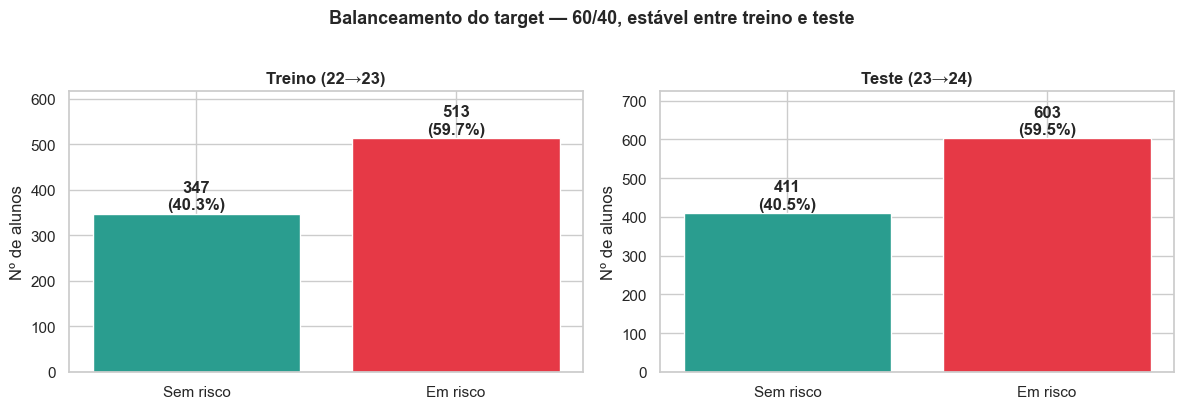

In [4]:
# Visualização do balanceamento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, label in zip(axes, [treino, teste], ["Treino (22→23)", "Teste (23→24)"]):
    counts = df["risco"].value_counts().sort_index()
    cores = ["#2a9d8f", "#e63946"]
    bars = ax.bar(["Sem risco", "Em risco"], counts.values, color=cores)
    for bar, v in zip(bars, counts.values):
        pct = v / counts.sum() * 100
        ax.text(bar.get_x() + bar.get_width() / 2, v + 10,
                f"{v}\n({pct:.1f}%)", ha="center", fontweight="bold")
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Nº de alunos")
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle("Balanceamento do target — 60/40, estável entre treino e teste",
             fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fe_balanceamento_target.png", dpi=150, bbox_inches="tight")
plt.show()

### leitura do balanceamento

- treino: 59.7% em risco (513 de 860)
- teste: 59.5% em risco (603 de 1014)

balanceamento quase idêntico entre treino e teste é um bom sinal — significa que o target é estável no tempo. a regra do target é robusta.

como a classe majoritária é "em risco" (60%), o desbalanceamento é leve. não preciso de SMOTE ou reamostragem; `class_weight='balanced'` nos modelos resolve se houver necessidade.

## 3. feature engineering

crio 3 categorias de features:

**snapshot (valores em t)** — os 7 indicadores principais (INDE, IAN, IDA, IEG, IAA, IPS, IPV) + metadados básicos do aluno (idade, fase, gênero, pedra, anos no programa, notas escolares).

**features de engenharia** — derivadas dos insights das perguntas de negócio:

- `gap_iaa_ida` — captura o efeito Dunning-Kruger da P4 (alunos que superestimam)
- `gap_ieg_ida` — captura "engajado mas sem performance"
- `ips_zscore_fase` — neutraliza a anomalia do IPS em 2023 detectada na P5
- `inde_zscore_fase` — posição relativa do aluno dentro da própria fase
- `ranking_inde_fase` — percentil do aluno na fase (0 = pior, 1 = melhor)

**contexto** — `anos_no_programa`, `fase`, `idade`, `pedra_nivel` (como ordinal).

IPP fica fora: o IPP não existe em 2022 (só aparece em 2023). como o treino é 22→23, incluir IPP geraria schema inconsistente entre treino (sem IPP) e teste (com IPP). decidi dropar IPP do modelo principal e documentar como limitação. uma v2 do modelo no futuro pode usar IPP quando disponível.

In [5]:
def engenharia_features(df):
    """
    Cria o DataFrame de features derivadas a partir dos dados de um ano (com
    target já calculado por construir_target).

    Schema FIXO — IPP excluído pra manter consistência treino/teste.
    """
    X = pd.DataFrame()

    # === 🟦 SNAPSHOT: indicadores e metadados no ano t ===
    for ind in ["inde", "ian", "ida", "ieg", "iaa", "ips", "ipv"]:
        X[ind] = df[ind]

    X["fase"] = df["fase"]
    X["idade"] = df["idade"]
    X["anos_no_programa"] = df["anos_no_programa"]
    X["ano_ingresso"] = df["ano_ingresso"]
    X["defasagem"] = df["defasagem"]

    # Gênero: 1 se menina, 0 caso contrário
    X["is_menina"] = (df["genero"].str.lower().str.contains("menina", na=False)).astype(int)

    # Pedra como ordinal (Quartzo=0, Topázio=3)
    X["pedra_nivel"] = df["pedra"].map(ORDEM_PEDRAS)

    # Notas brutas
    X["nota_mat"] = df["nota_mat"]
    X["nota_port"] = df["nota_port"]
    X["nota_ing"] = df["nota_ing"]
    X["tem_nota_ingles"] = df["tem_nota_ingles"].astype(int)

    # === 🟩 ENGENHARIA ===

    # Gap Dunning-Kruger (insight P4: 65% dos alunos superestimam)
    X["gap_iaa_ida"] = df["iaa"] - df["ida"]

    # Gap engajamento-desempenho ("engajado mas sem performance")
    X["gap_ieg_ida"] = df["ieg"] - df["ida"]

    # Média só de Mat+Port (robusta ao missing estrutural do inglês)
    X["media_notas_escolares"] = df[["nota_mat", "nota_port"]].mean(axis=1)

    # Z-score do IPS dentro da fase (neutraliza anomalia 2023 da P5)
    df_aux = df.copy()
    df_aux["ips_mean_fase"] = df_aux.groupby("fase")["ips"].transform("mean")
    df_aux["ips_std_fase"] = df_aux.groupby("fase")["ips"].transform("std")
    X["ips_zscore_fase"] = (df_aux["ips"] - df_aux["ips_mean_fase"]) / df_aux["ips_std_fase"]

    # Z-score do INDE dentro da fase (posição relativa)
    df_aux["inde_mean_fase"] = df_aux.groupby("fase")["inde"].transform("mean")
    df_aux["inde_std_fase"] = df_aux.groupby("fase")["inde"].transform("std")
    X["inde_zscore_fase"] = (df_aux["inde"] - df_aux["inde_mean_fase"]) / df_aux["inde_std_fase"]

    # Ranking percentil na fase (0 = pior, 1 = melhor)
    X["ranking_inde_fase"] = df.groupby("fase")["inde"].rank(pct=True)

    return X


X_train = engenharia_features(treino)
X_test = engenharia_features(teste)
y_train = treino["risco"].values
y_test = teste["risco"].values

print(f"✅ X_train: {X_train.shape}")
print(f"✅ X_test:  {X_test.shape}")
print(f"\nSchema idêntico? {list(X_train.columns) == list(X_test.columns)}")
print(f"\nFeatures ({X_train.shape[1]}):")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {col}")

✅ X_train: (860, 24)
✅ X_test:  (1014, 24)

Schema idêntico? True

Features (24):
   1. inde
   2. ian
   3. ida
   4. ieg
   5. iaa
   6. ips
   7. ipv
   8. fase
   9. idade
  10. anos_no_programa
  11. ano_ingresso
  12. defasagem
  13. is_menina
  14. pedra_nivel
  15. nota_mat
  16. nota_port
  17. nota_ing
  18. tem_nota_ingles
  19. gap_iaa_ida
  20. gap_ieg_ida
  21. media_notas_escolares
  22. ips_zscore_fase
  23. inde_zscore_fase
  24. ranking_inde_fase


In [6]:
# Diagnóstico de missing nas features
print("Missing por feature (treino):")
miss_train = (X_train.isna().sum() / len(X_train) * 100).round(1)
miss_train = miss_train[miss_train > 0].sort_values(ascending=False)
if len(miss_train) > 0:
    print(miss_train.to_string())
else:
    print("  (nenhum missing)")

print("\nMissing por feature (teste):")
miss_test = (X_test.isna().sum() / len(X_test) * 100).round(1)
miss_test = miss_test[miss_test > 0].sort_values(ascending=False)
if len(miss_test) > 0:
    print(miss_test.to_string())
else:
    print("  (nenhum missing)")

Missing por feature (treino):
nota_ing                 67.1
nota_mat                  0.2
nota_port                 0.2
media_notas_escolares     0.2

Missing por feature (teste):
nota_ing                 67.1
inde                      8.2
pedra_nivel               8.2
inde_zscore_fase          8.2
ranking_inde_fase         8.2
ida                       7.6
nota_mat                  7.6
nota_port                 7.6
gap_iaa_ida               7.6
gap_ieg_ida               7.6
media_notas_escolares     7.6
ieg                       7.5
ipv                       7.5
ips                       6.8
ips_zscore_fase           6.8
iaa                       6.2


### leitura do missing

- treino: só `nota_ing` tem missing alto (67%) — é o missing estrutural do inglês (só algumas fases têm avaliação). resolvido pela feature `tem_nota_ingles`.
- teste: tem mais missing porque inclui os universitários (fases 7-9) que entraram em 2023/2024 sem avaliação completa. é informativo, não aleatório.

decidi deixar os missings como estão. XGBoost e LightGBM lidam nativamente com NaN — eles aprendem sozinhos a melhor direção quando encontram um missing. pra LogReg e modelos lineares, vou imputar com mediana dentro do pipeline. nada de imputação a priori no X.

## 4. sanity check preliminar

antes de partir pra modelagem, faço uma regressão logística rápida pra confirmar que:

1. o pipeline está funcionando end-to-end
2. as features carregam sinal (AUC > 0.5)
3. as features mais importantes fazem sentido conceitual

isso não é o modelo final. é só um smoke test pra pegar bugs antes da etapa 4b.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

pipe_smoke = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

pipe_smoke.fit(X_train, y_train)
pred = pipe_smoke.predict(X_test)
proba = pipe_smoke.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, proba)
print(f"🎯 ROC-AUC (sanity check): {auc:.3f}")
print(f"\nMatriz de confusão:")
cm = confusion_matrix(y_test, pred)
print(f"                pred 0  pred 1")
print(f"  real 0 (SR) :  {cm[0,0]:4d}    {cm[0,1]:4d}")
print(f"  real 1 (ER) :  {cm[1,0]:4d}    {cm[1,1]:4d}")
print(f"\n{classification_report(y_test, pred, target_names=['Sem risco', 'Em risco'])}")

🎯 ROC-AUC (sanity check): 0.707

Matriz de confusão:
                pred 0  pred 1
  real 0 (SR) :   387      24
  real 1 (ER) :   438     165

              precision    recall  f1-score   support

   Sem risco       0.47      0.94      0.63       411
    Em risco       0.87      0.27      0.42       603

    accuracy                           0.54      1014
   macro avg       0.67      0.61      0.52      1014
weighted avg       0.71      0.54      0.50      1014



Top 10 features por |coeficiente| (LogReg):
  idade                    : +1.030  ↑ risco
  inde_zscore_fase         : -0.681  ↓ risco
  pedra_nivel              : +0.593  ↑ risco
  ieg                      : -0.564  ↓ risco
  ian                      : +0.363  ↑ risco
  ida                      : -0.334  ↓ risco
  ips                      : +0.332  ↑ risco
  fase                     : -0.322  ↓ risco
  tem_nota_ingles          : -0.309  ↓ risco
  ranking_inde_fase        : +0.270  ↑ risco


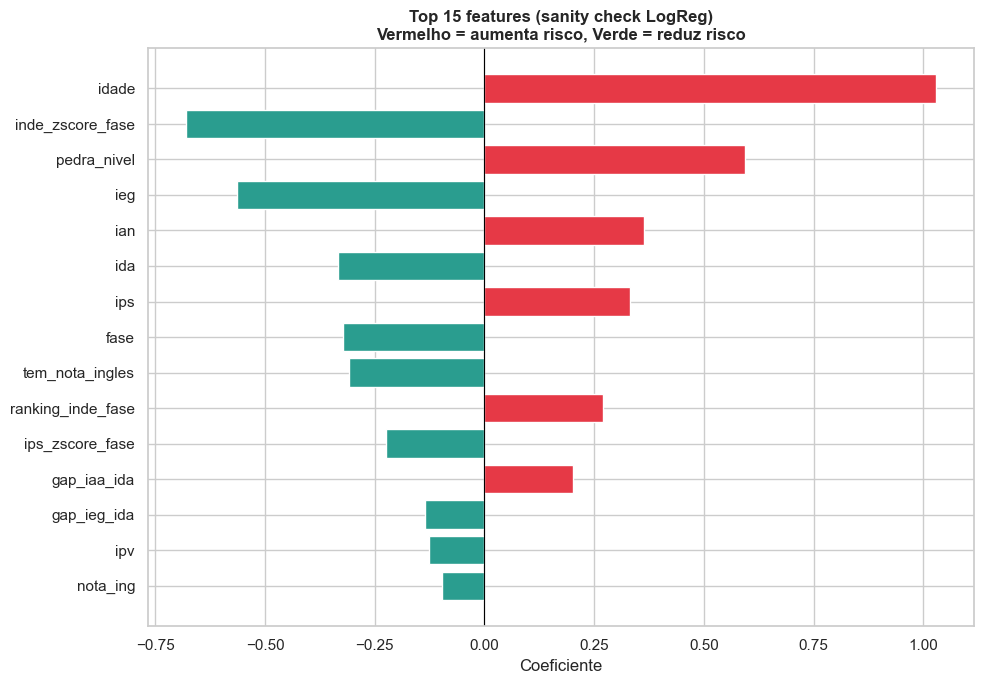

In [8]:
# Feature importance preliminar (coeficientes da LogReg)
coefs = pd.Series(
    pipe_smoke.named_steps["lr"].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

print("Top 10 features por |coeficiente| (LogReg):")
for feat, val in coefs.head(10).items():
    direcao = "↑ risco" if val > 0 else "↓ risco"
    print(f"  {feat:25s}: {val:+.3f}  {direcao}")

# Visualização
fig, ax = plt.subplots(figsize=(10, 7))
top15 = coefs.head(15).iloc[::-1]
cores_coef = ["#e63946" if v > 0 else "#2a9d8f" for v in top15.values]
ax.barh(range(len(top15)), top15.values, color=cores_coef)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 15 features (sanity check LogReg)\n"
             "Vermelho = aumenta risco, Verde = reduz risco", fontweight="bold")
ax.set_xlabel("Coeficiente")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fe_sanity_check_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Investigação: o coeficiente de pedra_nivel é contraintuitivo?
# Vamos ver a taxa de risco por pedra nos dois splits
print("Taxa de risco por pedra:")
print()
for label, df in [("Treino (22→23)", treino), ("Teste (23→24)", teste)]:
    print(f"{label}:")
    tabela = df.groupby("pedra")["risco"].agg(["mean", "count"]).round(3)
    tabela = tabela.reindex(["Quartzo", "Ágata", "Ametista", "Topázio"])
    print(tabela.to_string())
    print()

Taxa de risco por pedra:

Treino (22→23):
           mean  count
pedra                 
Quartzo   0.871    132
Ágata     0.632    250
Ametista  0.491    348
Topázio   0.531    130

Teste (23→24):
           mean  count
pedra                 
Quartzo   0.861     72
Ágata     0.699    246
Ametista  0.465    381
Topázio   0.513    232



### leitura do sanity check

ROC-AUC ≈ 0.71 — acima de 0.5 (aleatório) e abaixo de 0.85 (excelente). bom sinal: as features carregam informação real, mas ainda há espaço pra modelos mais sofisticados (GBMs tipicamente ganham 0.05-0.10 de AUC sobre LogReg em tabular).

features importantes batem com a narrativa das perguntas:

- `inde_zscore_fase` — posição relativa do aluno na fase é fortíssimo preditor
- `ieg`, `ian`, `ida` — os indicadores-chave identificados na P7
- `idade` — adolescentes e jovens adultos evadem mais (P10)

### achado contraintuitivo: o risco por pedra não é monotônico

olhando a tabela acima, dá pra ver:

- Quartzo: 87% de risco
- Ágata: 70%
- Ametista: 47%
- Topázio: 51%

Topázio tem mais risco que Ametista, o que parece errado à primeira vista. mas é um achado real:

- alunos Topázio estão no teto do INDE — matematicamente, só têm pra onde cair. a regra (a) do target (queda ≥ 0.5) pega eles com mais facilidade.
- Topázio pode regredir pra Ametista — Ametista também pode pra Ágata, mas Topázio começa "mais exposto" a cair 1 nível.
- é regressão à média estatística clássica.

implicação pra modelagem: a feature `pedra_nivel` como ordinal linear perde esse padrão não-monotônico. modelos lineares (LogReg) vão interpretar como "mais alta a pedra = mais risco", que é parcialmente verdade mas perde a nuance. GBMs (XGBoost, LightGBM) conseguem capturar a não-linearidade via divisões em árvore — espero que ganhem do LogReg justamente nesse tipo de padrão.

obs: o recall pra classe "em risco" ficou baixo no threshold default de 0.5. na etapa 4b vou ajustar o threshold pra maximizar recall, que é a métrica que importa pra ONG (perder aluno em risco é pior que falso positivo).

## 5. export dos datasets

salvo 4 arquivos parquet em `data/processed/`:

- `X_train.parquet` / `y_train.parquet` — 860 alunos de 2022 com target de 2023
- `X_test.parquet` / `y_test.parquet` — 1014 alunos de 2023 com target de 2024

e também os metadados pra análise de erros na etapa 4d:

- `treino_metadata.parquet` / `teste_metadata.parquet` — RA, fase, pedra, regras individuais do target

In [10]:
# Salvar datasets de modelagem
X_train.to_parquet(DATA_PROCESSED / "X_train.parquet", index=False)
X_test.to_parquet(DATA_PROCESSED / "X_test.parquet", index=False)
pd.Series(y_train, name="risco").to_frame().to_parquet(DATA_PROCESSED / "y_train.parquet", index=False)
pd.Series(y_test, name="risco").to_frame().to_parquet(DATA_PROCESSED / "y_test.parquet", index=False)

# Salvar metadados pra análise de erros
cols_meta = ["ra", "fase", "pedra", "inde", "idade", "genero",
             "risco", "r_queda", "r_regr", "r_evad", "r_p25"]
treino[cols_meta].to_parquet(DATA_PROCESSED / "treino_metadata.parquet", index=False)
teste[cols_meta].to_parquet(DATA_PROCESSED / "teste_metadata.parquet", index=False)

print("✅ Arquivos salvos em data/processed/:")
for arquivo in ["X_train", "y_train", "X_test", "y_test",
                "treino_metadata", "teste_metadata"]:
    path = DATA_PROCESSED / f"{arquivo}.parquet"
    if path.exists():
        print(f"  {arquivo}.parquet  ({path.stat().st_size / 1024:.1f} KB)")

# Sanity read-back
X_train_rb = pd.read_parquet(DATA_PROCESSED / "X_train.parquet")
assert X_train_rb.shape == X_train.shape, "Erro no read-back!"
print("\n✅ Read-back OK")

✅ Arquivos salvos em data/processed/:
  X_train.parquet  (47.2 KB)
  y_train.parquet  (1.3 KB)
  X_test.parquet  (54.5 KB)
  y_test.parquet  (1.3 KB)
  treino_metadata.parquet  (16.6 KB)
  teste_metadata.parquet  (21.2 KB)

✅ Read-back OK


## resumo da etapa 4a

dataset pronto pra modelagem:

- 24 features (consistentes entre treino e teste)
- treino: 860 alunos com features de 2022 e target de 2023 (60% em risco)
- teste: 1014 alunos com features de 2023 e target de 2024 (60% em risco)

features criadas:

- 7 indicadores + 8 metadados (snapshot em t)
- 6 features de engenharia (gaps, z-scores, rankings)
- 3 features de contexto temporal (anos no programa, fase, idade)

sanity check: ROC-AUC de ~0.71 com LogReg simples confirma que as features têm sinal. as features mais importantes fazem sentido conceitual (posição relativa no INDE, pedra, engajamento, idade).

o que fica pra etapa 4b:

- treinar e comparar 3 modelos: LogReg (baseline), XGBoost, LightGBM
- ajustar threshold pra maximizar recall (critério de negócio: não perder alunos em risco)
- avaliar com ROC-AUC, PR-AUC, F1, recall, matriz de confusão
- selecionar modelo final e serializar pra `models/`

limitações documentadas:

- IPP excluído por inconsistência entre treino (sem IPP em 2022) e teste (com IPP em 2023)
- apenas 2 pares disponíveis (22→23, 23→24) — não há histórico mais longo
- target inclui evasão — diferente de outros trabalhos que preveem só queda de performance

próximo passo: etapa 4b — modelagem tabular (`04_modelagem_tabular.ipynb`).